In [11]:
%load_ext autoreload
%autoreload 2

#### Generate a Dataset of Causal Patterns with different Causal Structures
1. Fundamentally, we work with Sequential models, 1D is our space and we have to predict next token 
2. Thus Features that we inherit "naturally" from the space itself are: 
    - Absolute Position
    - Module Divisibility (odd / even, each 3rd, each 5th, etc)
    - Relative Position (contextual on anchored token / set of tokens)
    - + **non-causal** global statistics, function of `len(seq)`, e.g. odd/even number of tokens
3. Here the only Positional Feature that we use is `Parity` (odd / even)
    - Though we can ignore Positional Features all together as well!
4. Non-Positional Features can be encoded by 
    - Compositions **of N** Tokens (must be `N > 1`)
    - Compositional Structre ***within*** Vocabulary 
5. Below are examples of **Non-Positional** Causal Sequences 
    - Non-Positional means that they should be treated as `Sets`

| Non-Positional Causal Patterns        | Comment                                        |
|----------------|------------------------------------------------|
| `a a a a a ...`| constant                         |
| `a b a b b ...`| **random** - Track model `Uncertaiinty`!       |
| `+a +a -b +a ...`| Two Token, `+:a` and `-:b`, `+/-` are **random** and causally control `a/b` !      |
| `-a +A +A -A ...`| `+:a` and `-:A`, `+/-` are **random** and causally control `a/A`      |
| `-a -b +A +B ...`| `+:lower` and `-:upper`, `+/-`  causally control `lower/upper`, `+/-` **and** `a/b` are **random**         |
| `-a -b +a +B ...`| `+:lower\|a` and `-:upper\|b`, `+/-`  and `a/b` are **random**, `+/-` causally control `lower/upper` only for `b` !!|
| `a- A+ b- B+ ...`| `lower:-` and `upper:+`, `a/b` and `lower/upper` are random, `lower/upper` controls `+/-`|
| `a- A- b- B+ ...`| only `B` leads to `+`, thus `a,A,b` can be considered as *joint vocabulary*, `a/b` and `lower/upper` merge!!|
| `-ab +AB +AB -ab ...`| Three Token, `-:lower` and `+:upper`, `a`  first `b` second       |
| `-ab +Ab +Ab -ab ...`| `+/-` controls `a/A` and `b` is constant (= independent)         |
| `-ab +AB +AB -ab ...`| Three Token, but `ab` / `AB` can be considered as a single one! `+/-` causal!        |
| `-aa +AA +BA -ba ...`|  `-:lower` and `+:upper`, `ll` both position and ***identity*** are **arbitrary**    |
| `+Ab -aB -aB +Ab ...`|  `+:upper\|first` and `-:upper\|second`, `ll` is always `ab`  |
| `-bA +Ab +Bb -bB ...`|  `+:upper\|first` and `-:upper\|second`, `ll` are arbitrary, but `lower:upper` of the third token is controled by `+/-`   |

We can have **"internal"** (within "word") `Positional Dependencies` arising from `global constraint` on Statistics (Total Count for Features fixed)
| Internal-Positional Causal Patterns        | Comment                                        |
|----------------|------------------------------------------------|
| `-ba +AB +BA -ab ...`|  `-:lower` and `+:upper`, `ab\|ba` position is ***arbitrary***, but both `a` and `b` must be present **once** (`global  constraint`!)    |
| `+Ab +Ba +bA -aB -bA ...`|  `+:upper\|first` and `-:upper\|second`, `ll` is either `ab` or `ba`, so  `global constraint` exists!  |

Sequence-Positional Features (only `Parity`!) included - now we can get `Oscillatory Patterns`!
| Pattern        | Comment                                        |
|----------------|------------------------------------------------|
| `a a a a a ...`| Single attribute, constant over all positions. |
| `a b a b a ...`| Binary attribute alternating by position.      |
| `a1 b1 a1 b1...`| `parity:a\|b` alternating with constant digit `1` . |
| `a2 b2 a2 b2...`| `parity:a\|b` alternating with constant digit `2` . |
| `a1 b2 a1 b2...`| `parity:token` consider `a1\|b2` as two tokens! |
| `a1 b2 b1 a2...`| `parity:digit` and `a\|b` **random** |
| `a1 b2 a1 b2...`| `parity:a\|b` and `a\|b:digit` **two-step** causal $\equiv$ `token-merging` for ***binary*** features|

Here's the table of exemplary patterns, starting from the simplest and moving to more complex combinations:

| Pattern        | Comment                                        |
|----------------|------------------------------------------------|
| `a a a a a ...`| Single attribute, constant over all positions. |
| `a b a b a ...`| Binary attribute alternating by position.      |
| `0 1 0 1 0 ...`| Numerical attribute alternating by parity.     |
| `< > < > < ...`| Directional symbol alternating by position.    |
| `a1 a1 a1 ...` | Two symbols: single letter, constant digit.    |
| `a1 b1 a1 b1...`| Binary attribute alternating with constant digit. |
| `a1 b2 a1 b2...`| Causal link: binary attribute paired with changing digit. |
| `b1 a2 b1 a2...`| Alternating symbols with parity-dependent digit. |
| `+a -b +a -b...`| Binary alternation with sign and alphabetic pairs. |
| `+1 -1 +1 -1...`| Signs alternating with constant numerical attribute. |
| `a A a A a ...`| Alternating case on the same letter.           |
| `a B a B a ...`| Lower/Upper case mix with alternating letters. |
| `x1 o2 x1 o2...`| Alternating markers paired with changing digits. |
| `(0) (1) (0)...`| Bracketed numerical pattern alternating by parity. |
| `{+} {-} {+}...`| Alternating signs enclosed in brackets.       |


In [167]:
import numpy as np
np.log10(1e6*(33000/1000))

7.518513939877887

In [2]:
import numpy as np
from geomechinterp.causal.pattern_generator import (
    get_all_possible_causal_patterns_labeled,
    realize_causal_pattern,
    generate_pattern,
)
from geomechinterp.causal.base_functions import ALL_BINARY_GENERATORS
from geomechinterp.causal.base_functions import ALL_BINARY_FEATURES
from geomechinterp.causal.utils import print_causal_structures


In [3]:
binary_features = ['ab', '+-']

explicit_patterns, patterns = get_all_possible_causal_patterns_labeled(binary_features)
permuts = list(patterns.keys())

print('Permutations of Features:', permuts)
print(f'Examples of Causal Structure:', patterns[permuts[0]])
for perm, causal_structure in patterns.items():
    print_causal_structures(causal_structure)


Permutations of Features: [('ab', '+-'), ('+-', 'ab')]
Examples of Causal Structure: [(('ab', ()), ('+-', ('ab',)))]
[
  ab: free
  +-: {ab}
]
[
  +-: free
  ab: free
]
[
  +-: free
  ab: {+-}
]


In [4]:
binary_features = ['ab', '+-', 'case']

explicit_patterns, patterns = get_all_possible_causal_patterns_labeled(binary_features)
permuts = list(patterns.keys())

print('Note that the number of causal structures rises super-exponentially with the number of features!')
print('Permutations of Features:', permuts)
print(f'Examples of Causal Structure:', patterns[permuts[0]])
for perm, causal_structure in patterns.items():
    print_causal_structures(causal_structure, print_indirect=True)

Note that the number of causal structures rises super-exponentially with the number of features!
Permutations of Features: [('ab', '+-', 'case'), ('ab', 'case', '+-'), ('+-', 'ab', 'case')]
Examples of Causal Structure: [(('ab', ()), ('+-', ('ab',)), ('case', ())), (('ab', ()), ('+-', ('ab',)), ('case', ('+-',))), (('ab', ()), ('+-', ('ab',)), ('case', ('+-', 'ab')))]
[
  ab: free
  +-: {ab}
  case: free
]
[
  ab: free
  +-: {ab}
  case: {ab -> +-}
]
[
  ab: free
  +-: {ab}
  case: {ab -> +-; ab}
]
[
  ab: free
  case: free
  +-: {case}
]
[
  ab: free
  case: {ab}
  +-: free
]
[
  ab: free
  case: free
  +-: {ab; case}
]
[
  ab: free
  case: {ab}
  +-: {ab -> case}
]
[
  ab: free
  case: {ab}
  +-: {ab}
]
[
  ab: free
  case: {ab}
  +-: {ab; ab -> case}
]
[
  +-: free
  ab: free
  case: free
]
[
  +-: free
  ab: free
  case: {+-}
]
[
  +-: free
  ab: free
  case: {+-; ab}
]
[
  +-: free
  ab: {+-}
  case: free
]
[
  +-: free
  ab: {+-}
  case: {+- -> ab}
]
[
  +-: free
  ab: {+-}
  cas

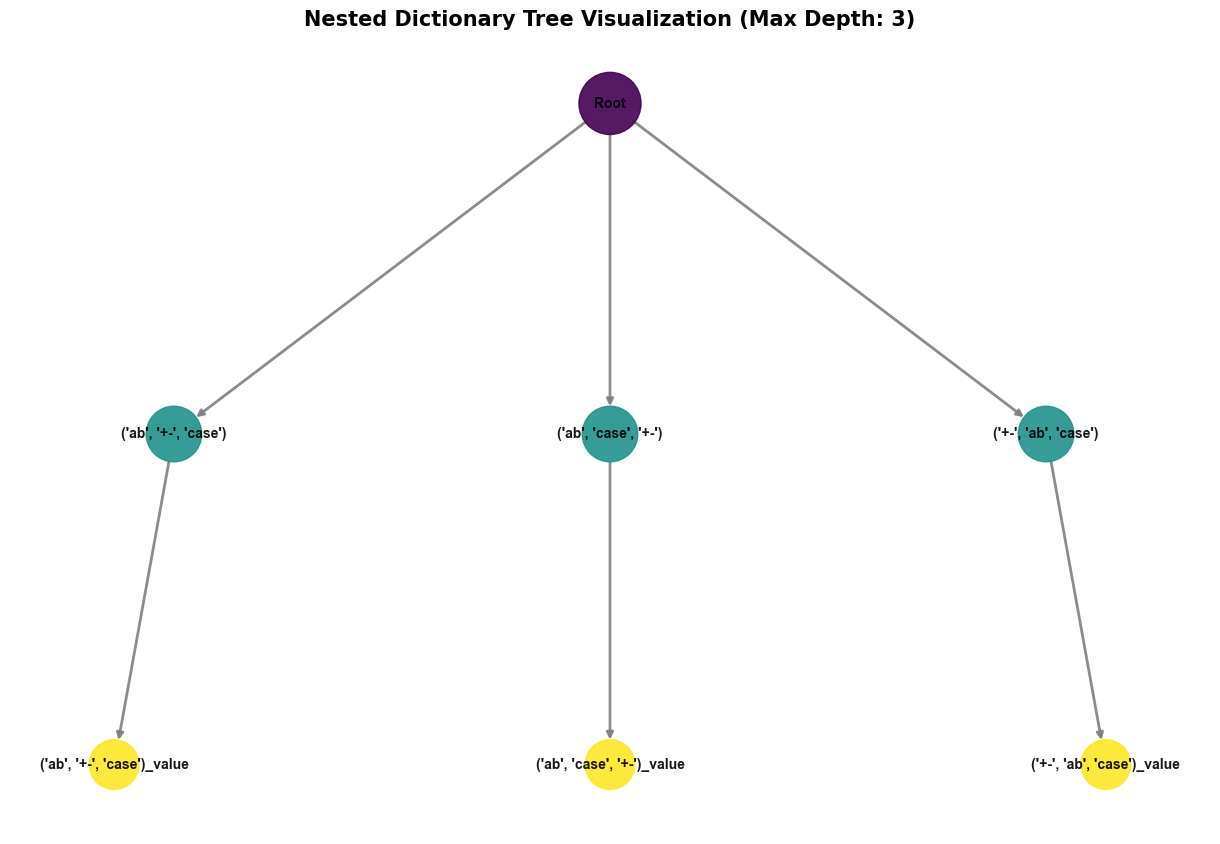

In [20]:
from geomechinterp.viz.plots import visualize_dict_structure_tree, display_graph_tree

graph = visualize_dict_structure_tree(patterns, max_depth=3)
display_graph_tree(graph, max_depth=3)

In [39]:
# current feature depends on *two* previous feature 
# possible inputs are 
# 0 0 
# 0 1
# 1 0 
# 1 1
# this is a Logical Gate!
# we will look at how LLMs solve Logical Circuits
# AND 
# OR
# XOR
# NAND
# 1 =>
# 2 =>
# !1 =>
# !2 =>
# +a, +b, -a, -b
# +a1, +b1, -a1, -b1 = constant 1
# +a2, +b2, -a2, -b2 = constant 2
# +a1, +b1, -a2, -b2 = +/- =>
# +a2, +b2, -a1, -b1 = !+/- =>
# +a1, +b2, -a1, -b2 = a/b =>
# +a2, +b1, -a2, -b1 = !a/b =>
# +a1, +b2, -a2, -b2 = a/b \land +/-
# +a2, +b1, -a1, -b1 = !(a/b \land +/-)
# +a1, +b1, -a1, -b2 = (a/b \lor +/-)
# +a2, +b2, -a2, -b1 = !(a/b \lor +/-)
# +a2, +b1, -a1, -b2 = (a/b \lor +/-) \land !(a/b \land +/-)

In [40]:
from geomechinterp.causal.pattern_generator import generate_truth_tables, apply_truth_table
# Example usage
N = 2
causal_truth_tables = generate_truth_tables(N, exclude_non_causal=True)

# Select the first causal truth table to apply
truth_table = causal_truth_tables[0]

print(f"Sampled Causal Operator:\n{truth_table}")

# New input sets to evaluate (M, N)
new_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.int8)

# Apply the selected truth table to the new inputs
outputs = apply_truth_table(truth_table, new_inputs)
print(f"Inputs:\n{new_inputs}")
print(f"Outputs:\n{outputs}")

Sampled Causal Operator:
[0 0 0 1]
Inputs:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Outputs:
[0 0 0 1]


In [41]:
len(generate_truth_tables(N, exclude_non_causal=True))

10

In [42]:
generate_truth_tables(N, exclude_non_causal=False)

array([[0, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 1, 0],
       [0, 0, 1, 1],
       [0, 1, 0, 0],
       [0, 1, 0, 1],
       [0, 1, 1, 0],
       [0, 1, 1, 1],
       [1, 0, 0, 0],
       [1, 0, 0, 1],
       [1, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 1, 0, 0],
       [1, 1, 0, 1],
       [1, 1, 1, 0],
       [1, 1, 1, 1]], dtype=int8)

In [170]:
# Generate truth table for 3 inputs with random outputs
import numpy as np
from itertools import product
from IPython.display import Markdown

size = 4
inputs = list(product([0,1], repeat=size))
outputs = np.random.randint(0,2,size=2**size)

# Create markdown table showing truth table
table = "| A | B | C | D | Output |\n|---|---|---|---|--------|\n"
for i, (a,b,c,d) in enumerate(inputs):
    table += f"| {a} | {b} | {c} | {d} | {outputs[i]} |\n"
    
Markdown(table)


| A | B | C | D | Output |
|---|---|---|---|--------|
| 0 | 0 | 0 | 0 | 0 |
| 0 | 0 | 0 | 1 | 1 |
| 0 | 0 | 1 | 0 | 0 |
| 0 | 0 | 1 | 1 | 0 |
| 0 | 1 | 0 | 0 | 0 |
| 0 | 1 | 0 | 1 | 0 |
| 0 | 1 | 1 | 0 | 0 |
| 0 | 1 | 1 | 1 | 1 |
| 1 | 0 | 0 | 0 | 0 |
| 1 | 0 | 0 | 1 | 1 |
| 1 | 0 | 1 | 0 | 0 |
| 1 | 0 | 1 | 1 | 0 |
| 1 | 1 | 0 | 0 | 1 |
| 1 | 1 | 0 | 1 | 1 |
| 1 | 1 | 1 | 0 | 0 |
| 1 | 1 | 1 | 1 | 1 |


In [288]:
from geomechinterp.causal.hasse import filter_truth_tables

all_tts = generate_truth_tables(3, exclude_non_causal=False)
print(all_tts.shape) # 2^2^3 x 2^3 = 2^8 x 8

filtered_tts = filter_truth_tables(all_tts, [None, 1, 0])
filtered_tts

(256, 8)


masked_array(
  data=[[--, --, 0, --, --, --, 0, --],
        [--, --, 0, --, --, --, 1, --],
        [--, --, 1, --, --, --, 0, --],
        [--, --, 1, --, --, --, 1, --]],
  mask=[[ True,  True, False,  True,  True,  True, False,  True],
        [ True,  True, False,  True,  True,  True, False,  True],
        [ True,  True, False,  True,  True,  True, False,  True],
        [ True,  True, False,  True,  True,  True, False,  True]],
  fill_value=999999,
  dtype=int8)

#### All Possible Truth Table Functions for N=2
| Index | Binary Pattern | Function Name | Description |
|-------|---------------|---------------|-------------|
| 0     |  0000 | CONSTANT_0 | Always outputs 0 |
| 2     |  0010 | A_AND_NOT_B | True when A=1 and B=0 |
| 1     |  0001 | AND | True only when all inputs are 1 |
| 3     |  0011 | A | Output equals first input |
| 4     |  0100 | NOT_A_AND_B | True when A=0 and B=1 |
| 5     |  0101 | B | Output equals second input |
| 6     |  0110 | XOR | True when inputs are different |
| 7     |  0111 | OR | True when any input is 1 |
| 8     |  1000 | NOR | True when both inputs are 0 |
| 9     |  1001 | XNOR | True when inputs are same |
| 10    |  1010 | NOT_B | Negation of second input |
| 11    |  1011 | A_OR_NOT_B | True when A=1 or B=0 |
| 12    |  1100 | NOT_A | Negation of first input |
| 13    |  1101 | NOT_A_OR_B | True when A=0 or B=1 |
| 14    |  1110 | NAND | False only when both inputs are 1 |
| 15    |  1111 | CONSTANT_1 | Always outputs 1 |


In [50]:
all_pat, dedup_pat = get_all_possible_causal_patterns_labeled(['position_parity','ab','case'])
print('All Permutations:', dedup_pat.keys())
print('Causal Structures for Permutation (position_parity, ab, case):')
dedup_pat[('position_parity', 'ab', 'case')]

All Permutations: dict_keys([('position_parity', 'ab', 'case')])
Causal Structures for Permutation (position_parity, ab, case):


[(('ab', ()), ('case', ())),
 (('ab', ()), ('case', ('ab',))),
 (('ab', ()), ('case', ('position_parity',))),
 (('ab', ()), ('case', ('ab', 'position_parity'))),
 (('ab', ('position_parity',)), ('case', ())),
 (('ab', ('position_parity',)), ('case', ('ab',))),
 (('ab', ('position_parity',)), ('case', ('position_parity',))),
 (('ab', ('position_parity',)), ('case', ('ab', 'position_parity')))]

In [308]:
causal_structure = [
                ('position_parity', ()),
                ('ab', ()),
                ('case', ('ab', 'position_parity')),
                ('+-', ('ab', 'position_parity'))
                ]
all_realized_functions = realize_causal_pattern(causal_structure, all_binary_generators=ALL_BINARY_GENERATORS)
print('total number of functions:', len(all_realized_functions))
func = all_realized_functions[-1]
func


total number of functions: 32


Chain of functions:
IndependentFeature(function=ab_f, global_control=1) (deterministic)
DependentFeature(function=case_f, controls=[ab, position_parity], truth_table=[--, --, 1, 1])
DependentFeature(function=plus_minus_f, controls=[ab, position_parity], truth_table=[--, --, 1, 1])

In [63]:
for stem in ['', 'a', 'b']:
    for pos in [1,2]:
        print(f'{pos} {stem if stem else " "}:', func(stem, position=pos))

1  : A+
2  : a-
1 a: AA+
2 a: aa-
1 b: BA+
2 b: ba-


In [309]:
# use "_prev" to indicate that the control comes from the previous token
# e.g. a+ B- a+ B- a+ B- ...
# here case B is controlled by ab_prev
# when **previous** token contains "a", then letter in current token becomes uppercase (b -> B)
causal_structure = [
                ('ab', ()),
                ('case', ('ab_prev', 'position_parity')),
                ('+-', ('ab', 'position_parity'))
                ]
all_realized_functions = realize_causal_pattern(causal_structure, all_binary_generators=ALL_BINARY_GENERATORS)
print('total number of functions:', len(all_realized_functions))
func = all_realized_functions[-1]
func

total number of functions: 80


Chain of functions:
IndependentFeature(function=ab_f, global_control=1) (deterministic)
DependentFeature(function=case_f, controls=[ab_prev, position_parity], truth_table=[1, 1, 1, 0])
DependentFeature(function=plus_minus_f, controls=[ab, position_parity], truth_table=[--, --, 1, 1])

In [310]:
# some patterns will become stationary no matter the prefix
# for func above, ab is deterministic and set to 1 - meaning "a"
# and the case is determined by the previous token being "a" or "b" AND the position parity
# any time we get "a" and odd position, we get uppercase
# from that point it is *impossible* to get lowercase again
generate_pattern(func, start_string='b+ a- b- a- b+ a-', pattern_length=25)

'b+ a- b- a- b+ a- : a+ A- A+ A- A+ A- A+ A- A+ A- A+ A- A+ A- A+ A- A+ A- A+ A- A+ A- A+ A- A+'

In [311]:
# some patterns are stochastic (in fact most of them are)
# stochastic patterns contain random components that (binary) fire with uniform probability 0.5 / 0.5
# for this example a/b choice is random
# case is upper when previous token contains "a" and position of token is even
# sign at the end is "+" when the current letter is "a" and position is odd
func = all_realized_functions[20]
print(func)
# Note that colorization should be used only for visual inspection, it turns string into HTML
generate_pattern(func, start_string='b+ a+', pattern_length=25, colorize=True)


Chain of functions:
IndependentFeature(function=ab_f, global_control=0) (deterministic)
DependentFeature(function=case_f, controls=[ab_prev, position_parity], truth_table=[1, 0, 0, 0])
DependentFeature(function=plus_minus_f, controls=[ab, position_parity], truth_table=[0, 0, --, --])


In [315]:
all_pat, dedup_pat = get_all_possible_causal_patterns_labeled(('position_parity', 'ab_prev', 'ab', 'case'), verbose=True)

patterns = []
unique_patterns_and_functions = []
for perm in dedup_pat.keys():
    for causal_structure in dedup_pat[perm]:
        all_realized_functions = realize_causal_pattern(causal_structure, all_binary_generators=ALL_BINARY_GENERATORS)
        for f in all_realized_functions:
            patterns.append(generate_pattern(f, pattern_length=25))
unique_patterns_and_functions = dict(zip(patterns, all_realized_functions))
# remove duplicates based on first element of tuple

print('Number of patterns / unique patterns:', len(patterns), '/', len(unique_patterns_and_functions))

list(unique_patterns_and_functions.keys())[:20]

INFO:root:all_causal_edge_lists:
INFO:root:Total Count: 64, Deduplicated Count: 32


Number of patterns / unique patterns: 3668 / 46


['b b b b b b b b b b b b b b b b b b b b b b b b b',
 'B B B B B B B B B B B B B B B B B B B B B B B B B',
 'a a a a a a a a a a a a a a a a a a a a a a a a a',
 'A A A A A A A A A A A A A A A A A A A A A A A A A',
 'a A a A a A a A a A a A a A a A a A a A a A a A a',
 'B b B b B b B b B b B b B b B b B b B b B b B b B',
 'b B b B b B b B b B b B b B b B b B b B b B b B b',
 'A a A a A a A a A a A a A a A a A a A a A a A a A',
 'a a A a A a A a A a A a A a A a A a A a A a A a A',
 'A a a a a a a a a a a a a a a a a a a a a a a a a',
 'A a a A A a a A A a a A A a a A A a a A A a a A A',
 'a a A A a a A A a a A A a a A A a a A A a a A A a',
 'a b a b a b a b a b a b a b a b a b a b a b a b a',
 'a B a B a B a B a B a B a B a B a B a B a B a B a',
 'A a B a B a B a B a B a B a B a B a B a B a B a B',
 'A a b a b a b a b a b a b a b a b a b a b a b a b',
 'b a b a b a b a b a b a b a b a b a b a b a b a b',
 'A b A b A b A b A b A b A b A b A b A b A b A b A',
 'b A b A b A b A b A b A b 

### Optimizing Performance by Prunning Exponential Space of Possible Causal Interactions

In [ ]:
import pickle
from geomechinterp.causal.pattern_generator import realize_causal_pattern, realize_causal_pattern
from geomechinterp.causal.truth_table_cache import truth_table_cache

causal_pattern = [
        ('ab', ('position_parity')),
        ('+-', ('ab_prev', 'position_parity')),
        ('case', ('ab', 'ab_prev', 'position_parity'))
        ]
generators_1 = realize_causal_pattern(causal_pattern)
generators_2 = realize_causal_pattern(causal_pattern)
print(len(generators_1), len(generators_2))
generators_1[0]
generators_2[0]

In [ ]:
s1, s2 = set([hash(g) for g in generators_1]), set([hash(g) for g in generators_2])
print(len(s1.intersection(s2)))
print(len(s1.difference(s2)))
print(len(s2.difference(s1)))

In [ ]:
# compare performance of generators_1 and generators_2
import time
start_time = time.time()
generators_1 = realize_causal_pattern(causal_pattern)
end_time = time.time()
print(f"Time taken for generators_1: {end_time - start_time} seconds")

start_time = time.time()
generators_2 = realize_causal_pattern(causal_pattern)
end_time = time.time()
print(f"Time taken for generators_2: {end_time - start_time} seconds")
